--- Model Performance Metrics ---
Mean Squared Error (MSE): 0.0889
R-squared (R2) Score:     0.9609

--- Top 10 Most Influential Features ---
Votes                                      0.944364
Longitude                                  0.011535
Latitude                                   0.008891
Average Cost for two                       0.004478
Country Code                               0.002773
Price range                                0.000610
Cuisines_North Indian, Chinese             0.000605
Currency_Indian Rupees(Rs.)                0.000531
Cuisines_Pizza, Fast Food                  0.000451
Cuisines_North Indian, Mughlai, Chinese    0.000422
dtype: float64


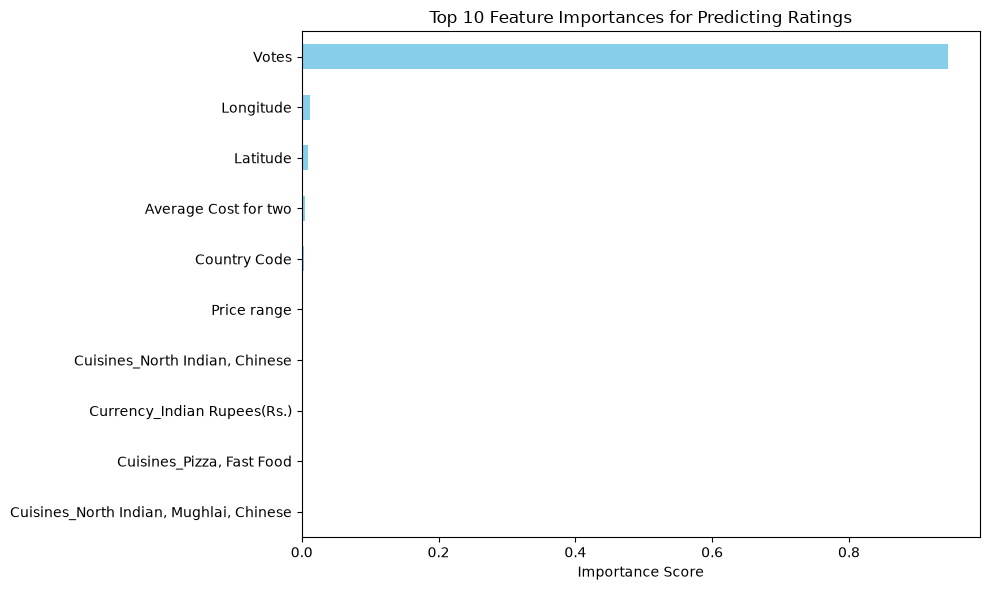

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

# Automatically prompt for the CSV file if not found locally
file_path = 'Dataset.csv'
if not os.path.exists(file_path):
    from tkinter import Tk
    from tkinter.filedialog import askopenfilename
    Tk().withdraw()
    file_path = askopenfilename(
        title="Select Dataset CSV File",
        filetypes=[("CSV Files", "*.csv"), ("All Files", "*.*")]
    )

df = pd.read_csv(file_path, encoding='utf-8-sig')
df.columns = df.columns.str.strip()

# 2. Define Features and Target
target = 'Aggregate rating'

drop_keywords = [
    'Restaurant ID',
    'Restaurant Name',
    'Address',
    'Locality Verbose',
    'Rating color',
    'Rating text',
    target
]

# Drop target leakage and identifier columns
cols_to_drop = [
    col for col in df.columns 
    if any(kw.lower() in col.lower() for kw in drop_keywords)
]

X = df.drop(columns=cols_to_drop)
y = df[target]

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

# 3. Preprocessing Pipelines
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Model Training
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

model_pipeline.fit(X_train, y_train)

# 6. Evaluation Metrics
y_pred = model_pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R-squared (R2) Score:     {r2:.4f}\n")

# 7. Feature Importance Analysis
preproc = model_pipeline.named_steps['preprocessor']
cat_encoder = preproc.named_transformers_['cat'].named_steps['onehot']
encoded_cat_cols = cat_encoder.get_feature_names_out(cat_cols).tolist()
feature_names = num_cols + encoded_cat_cols

importances = model_pipeline.named_steps['regressor'].feature_importances_
feat_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("--- Top 10 Most Influential Features ---")
print(feat_importances.head(10))

# Plot Top Features Inline
plt.figure(figsize=(10, 6))
feat_importances.head(10).plot(kind='barh', color='skyblue')
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importances for Predicting Ratings")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()